### Import libraries

In [38]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

### Load and clean the data

In [39]:
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv")

# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

# Select numerical features for PCA
X = df.select_dtypes(include=[np.number])
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Missing values:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


### Run PCA

Explained variance ratio: [0.72991022 0.22858172]


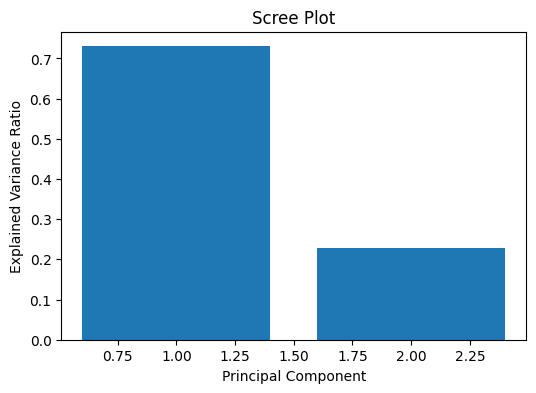

In [40]:
pca = PCA(n_components=2)  # Reduce to 2 components for visualization
X_pca = pca.fit_transform(X_scaled)

# Explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)

# Scree plot
plt.figure(figsize=(6,4))
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.show()

### Run and plot the Elbow Method

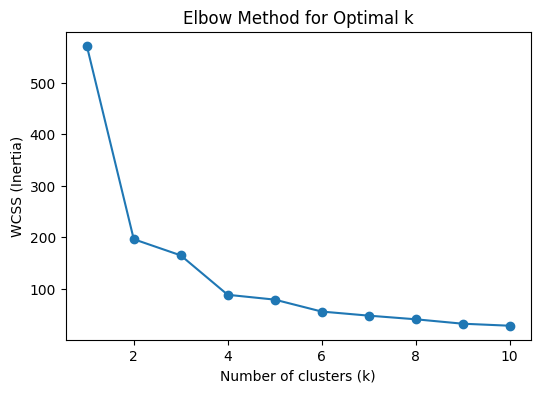

In [41]:
wcss = []  # within-cluster sum of squares
K_range = range(1, 11)  # testing k from 1 to 10
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(6,4))
plt.plot(K_range, wcss, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.show()

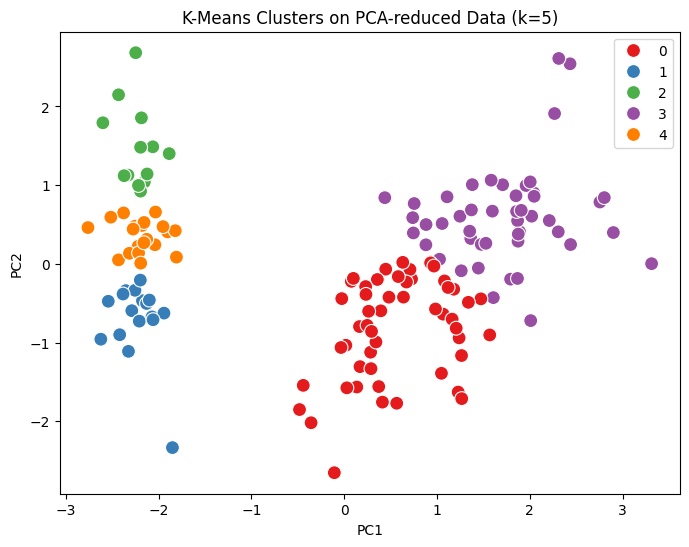

In [42]:
# Choose k based on elbow (for Iris dataset, k=3)
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(X_pca)
df['Cluster'] = clusters

# Visualize the clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="Set1", s=100)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-Means Clusters on PCA-reduced Data (k={optimal_k})")
plt.show()